# Marco Lopez CS6220 HW 1

## Import Iris Data

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


# Fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# Iris feature dataframe
X = iris.data.features 
# Iris target dataframe
y = iris.data.targets 
# Full Iris dataframe
df = pd.concat([X, y], axis=1)
# Reshape for ML compatability
y = np.ravel(y)

In [2]:
# View full dataframe
df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df["class"].value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: class, dtype: int64

## Data Visualization

This section creates a scatterplot that is like those shown on the Iris data Wikipedia page.

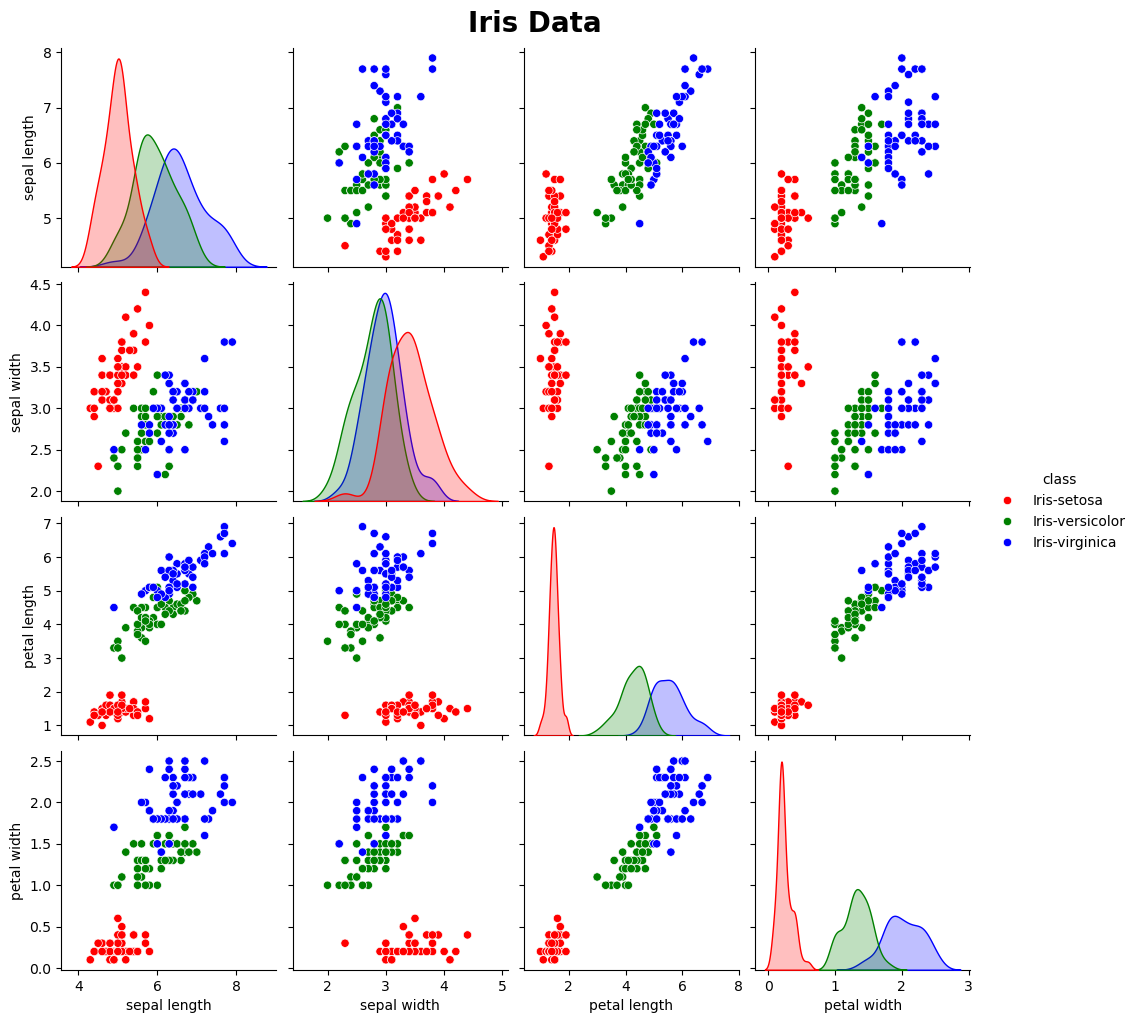

In [4]:
# Scatterplot similar to one on Wikipedia page

plot = sns.pairplot(df, hue="class", palette= {"Iris-setosa": "red", "Iris-versicolor": "green", "Iris-virginica": "blue"})

plot.fig.suptitle("Iris Data", x = 0.475, y = 1.02, fontsize = 20, fontweight = "bold")

plt.show()

## KNN model training

In this section, the K-Nearest Neighbors machine learning algorithm is trained to classify the Iris flowers from the dataset.

The code below splits the original Iris data into a training and test set, where 80% will be training data and 20% is test data.

In [5]:
# Split the dataset into training and test data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [6]:
# Value counts of test set

pd.Series(y_test).value_counts()

Iris-virginica     11
Iris-setosa        10
Iris-versicolor     9
dtype: int64

In this part, I am using a scikit-Learn pipeline abstraction to build my pipeline.

In [7]:
# Build machine learning pipeline for KNN classifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [8]:
# Obtain model accuracy

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model accuracy:", accuracy)

Model accuracy: 1.0


The model was trained on the train data and then evaluated on the test data.

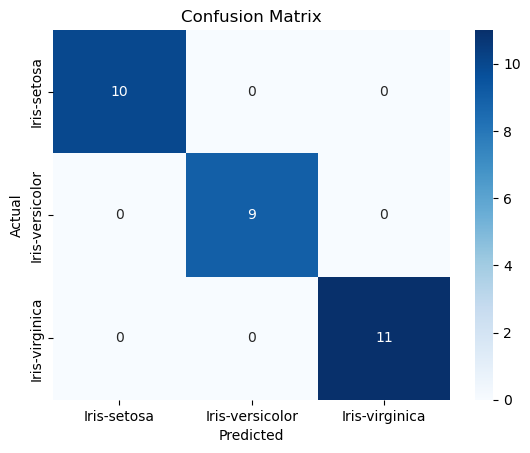

In [9]:
# Confusion matrix original

conf_matrix = confusion_matrix(y_test, y_pred)
labels = sorted(set(y_test))

sns.heatmap(conf_matrix, annot = True, cmap = "Blues", xticklabels = labels, yticklabels = labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Hyperparameter tuning

In this section, hyperparameter tuning is explored. Specifically, looking at the parameters of n_neighbors and weights. N_neighbors looks at how many neighbors the model looks at to make a prediction, while weights looks at how much influence each neighbor has on the prediction.

The n_neighbor parameters tested are all numbers from 1-10. While the weight parameter strategy is either uniform (all neighbors have equal weight) or distance (neighbors that are closer get a higher weight and influence).

In [10]:
# Explore model hyperparameter tuning

param_grid = {"model__n_neighbors": [1,2,3,4,5,6,7,8,9,10], "model__weights": ["uniform", "distance"]}

grid_search = GridSearchCV(pipeline, param_grid, cv = 5, scoring = "accuracy")

grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)

y_pred = grid_search.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("New test accuracy after hyperparameter tuning:", accuracy)

Best hyperparameters found: {'model__n_neighbors': 9, 'model__weights': 'distance'}
New test accuracy after hyperparameter tuning: 1.0


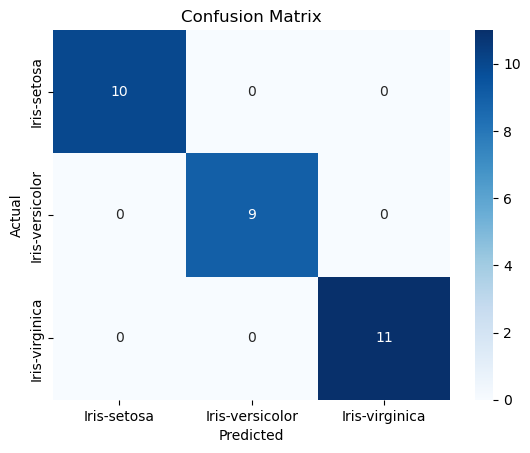

In [11]:
# Confusion matrix after hyperparameter tuning

conf_matrix = confusion_matrix(y_test, y_pred)
labels = sorted(set(y_test))

sns.heatmap(conf_matrix, annot = True, cmap = "Blues", xticklabels = labels, yticklabels = labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()